# 14 · E3e: drift, or colored input? Re-calibrating E3 against realistic nulls

**Why this notebook exists.** Every drift threshold in Notebooks 10–13 came from *stationary surrogates driven by white noise*. While building the control promised in Notebook 13, a problem appeared. The surrogates for this notebook keep a fixed program but drive it with the real recording's residuals, *high-passed* so that nothing slower than ~1 min remains, and phase-randomised. Such surrogates have no drift at all, yet on one recording they produce **refit − frozen gaps as large as the real ones** (+0.007 to +0.023, vs +0.004 real).

| one recording (2021-05-26-07) | refit − frozen gap | staleness slope (R² lost per window of distance) |
|---|---|---|
| real | +0.004 | **−0.068** |
| white-noise surrogate (the null of Notebooks 10–13) | −0.009 | −0.001 |
| colored surrogates, no power slower than 32 s / 64 s / 128 s | **+0.022** / +0.010 / ~0 | −0.009 / −0.008 / −0.005 |
| drive random-walk surrogate | +0.003 | −0.004 |

So:
* **The refit − frozen gap is not a clean drift statistic.** Re-estimating drives on the previous minute helps whenever the residual input is autocorrelated over tens of seconds, drift or not. E3's detection counts (47/68) and the gap-based analyses that built on them (E3c's families, E3d's tracker) may partly reflect stationary colored input.
* **The staleness slope is not fooled.** Colored input barely moves it, because it measures how forecasts degrade with *distance* in time, which stationary input cannot produce beyond its correlation time. This recording, which the gap called "no drift", goes stale ~8× faster than any null.

This notebook repeats E3's three statistics against **colored nulls**, recording by recording:
* the gap;
* the staleness slope (Notebook 10's temporal generalization);
* the online tracker's gain (Notebook 13).

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, glob, time, datetime, numpy as np, matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 13, 0), \
    f"Notebook 14 needs closurebench >= 0.13.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import drift as DR, drift_kinds as DK, drift_time as DT
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CONF = {"smoke": dict(N_COL=1, MAX_FILES=1), "laptop": dict(N_COL=2, MAX_FILES=None), "full": dict(N_COL=3, MAX_FILES=None)}[MODE]
globals().update(CONF)
CUT, CUT_SENS, GAP_FLOOR = 100, (50, 200), 0.005
TAG = "" if MODE == "full" else f"_{MODE}"
files = sorted(glob.glob(os.path.join(RESULTS, "spontaneous", "*.json")))[:MAX_FILES]
CK = os.path.join(RESULTS, "e3e_ck", MODE); os.makedirs(CK, exist_ok=True)
E3C_CK, E3D_CK = (os.path.join(RESULTS, d, MODE) for d in ("e3c_ck", "e3d_ck"))
print(f"{len(files)} recordings; {N_COL} colored nulls (cutoff {CUT} frames) + sensitivity cutoffs {CUT_SENS} + 1 drive random walk each")

68 recordings; 2 colored nulls (cutoff 100 frames) + sensitivity cutoffs (50, 200) + 1 drive random walk each


### Pre-registration (before §1)

Recorded in `results/E3e_preregistration*.json`.

**Colored nulls.** The frozen program is fitted to the whole recording and driven by its own residuals, high-passed at 100 frames (~64 s, half a forecast window) and phase-randomised: stationary, with the real fast autocorrelation. Two are drawn per recording.

* **R1 · GAP.** The refit − frozen gap exceeds the colored nulls' gap: a one-sided Wilcoxon test over recordings on gap_real − mean(gap_colored), p < 0.05. The per-recording re-detection count uses gap_real ≥ max(0.005, largest colored gap).
* **R2 · STALE.** Programs go stale with distance in time beyond colored input: a one-sided Wilcoxon test over recordings on mean(slope_colored) − slope_real > 0, p < 0.05. The slope is that of Notebook 10's temporal generalization (8 windows). Per recording, a recording counts as drifting if slope_real < the most negative colored slope.
* **R3 · TRACK.** The online tracker gains more than on colored input: a one-sided Wilcoxon test on (tracker − frozen)_real − mean over colored nulls, p < 0.05.

Descriptive only:
* cutoffs of 50 and 200 frames (sensitivity);
* the staleness slope of a drive random-walk surrogate of the size used in Notebooks 10–13 (drift_frac 0.07).

In [3]:
prereg = os.path.join(RESULTS, f"E3e_preregistration{TAG}.json")
plan = {"experiment": "E3e drift or colored input", "mode": MODE, "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "config": {**CONF, "CUT": CUT, "CUT_SENS": list(CUT_SENS), "GAP_FLOOR": GAP_FLOOR},
        "R1": "one-sided Wilcoxon gap_real - mean gap_colored > 0, p < 0.05",
        "R2": "one-sided Wilcoxon mean slope_colored - slope_real > 0, p < 0.05",
        "R3": "one-sided Wilcoxon (tracker-frozen)_real - mean over colored > 0, p < 0.05"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E3e_preregistration_laptop.json


## 1 · Per-recording analysis (checkpointed)

Real gaps and tracker gains are reused from Notebooks 12 and 13 when their checkpoints exist. About 1–1.5 minutes per recording on a laptop.

In [4]:
def stats(Y, S, U, tracker=True):
    s = {"gap": DK.family_scores(Y, S, U, families=("bias",))["gap"], "slope": DR.temporal_generalization(Y, S, U)[1]}
    if tracker:
        t = DT.tracker_scores(Y, S, U); s["track_gain"] = t["tracker"] - t["frozen"]
    return s

rec = {}
for f in files:
    name = os.path.basename(f).replace(".json", "")[-13:]
    ck = os.path.join(CK, name + ".json")
    if os.path.exists(ck):
        rec[name] = json.load(open(ck)); continue
    t0 = time.time()
    R = DR.load_atanas(f); X, U = R["X"], R["U"]
    S = ~np.eye(X.shape[1], dtype=bool)
    real = {"slope": DR.temporal_generalization(X, S, U)[1]}
    c3, d3 = os.path.join(E3C_CK, name + ".json"), os.path.join(E3D_CK, name + ".json")
    real["gap"] = json.load(open(c3))["real"]["gap"] if os.path.exists(c3) else DK.family_scores(X, S, U, families=("bias",))["gap"]
    if os.path.exists(d3):
        t = json.load(open(d3))["series"]["real"]["track"]; real["track_gain"] = t["tracker"] - t["frozen"]
    else:
        t = DT.tracker_scores(X, S, U); real["track_gain"] = t["tracker"] - t["frozen"]
    out = {"N": int(X.shape[1]), "real": real,
           "colored": [stats(Y, S, U) for Y in (DT.colored_surrogate(X, S, U, cut_frames=CUT, seed=700 + s) for s in range(N_COL)) if Y is not None],
           "sens": {}}
    for c in CUT_SENS:
        Y = DT.colored_surrogate(X, S, U, cut_frames=c, seed=800 + c)
        if Y is not None:
            out["sens"][str(c)] = stats(Y, S, U, tracker=False)
    Yr = DR.surrogate(X, S, U, seed=900, drift_frac=0.07)
    out["rw_slope"] = DR.temporal_generalization(Yr, S, U)[1] if Yr is not None else None
    json.dump(out, open(ck, "w"), default=float); rec[name] = out
    cg = [c["gap"] for c in out["colored"]]; cs = [c["slope"] for c in out["colored"]]
    print(f"{name}: gap {real['gap']:+.4f} vs colored {np.round(cg, 4)} | slope {real['slope']:+.4f} vs colored {np.round(cs, 4)}"
          f" | tracker gain {real['track_gain']:+.4f}  ({time.time() - t0:.0f} s)", flush=True)
print(f"{len(rec)} recordings analysed")

2021-05-26-07: gap +0.0043 vs colored [0.014 0.007] | slope -0.0682 vs colored [-0.0071 -0.0068] | tracker gain +0.0031  (52 s)
2021-06-11-01: gap +0.0212 vs colored [0.0006 0.006 ] | slope -0.0605 vs colored [-0.0062 -0.0047] | tracker gain +0.0479  (60 s)
2021-08-04-06: gap +0.0050 vs colored [-0.0018 -0.0019] | slope -0.0099 vs colored [-0.0057 -0.0068] | tracker gain +0.0075  (57 s)
2021-08-17-01: gap +0.0208 vs colored [-0.0008 -0.0001] | slope -0.0158 vs colored [-0.0109 -0.0092] | tracker gain +0.0176  (56 s)
2021-08-18-01: gap +0.0243 vs colored [ 0.0009 -0.0001] | slope -0.0234 vs colored [ 0.0004 -0.0003] | tracker gain +0.0368  (48 s)
2021-09-06-09: gap +0.0049 vs colored [-0.0008  0.0032] | slope -0.0076 vs colored [-0.0036 -0.0019] | tracker gain +0.0206  (48 s)
2021-09-14-01: gap +0.0625 vs colored [-0.0013 -0.0014] | slope +0.0080 vs colored [-0.0111 -0.0109] | tracker gain +0.0963  (52 s)
2021-09-14-05: gap +0.0030 vs colored [-0.0017 -0.0018] | slope -0.0317 vs colored

In [5]:
def wtest(x, alt="greater"):
    x = np.asarray(x, float)
    return float(wilcoxon(x, alternative=alt).pvalue) if len(x) >= 6 and np.any(x != 0) else float("nan")
ok = {k: o for k, o in rec.items() if o["colored"]}
g_real = np.array([o["real"]["gap"] for o in ok.values()]); g_col = np.array([np.mean([c["gap"] for c in o["colored"]]) for o in ok.values()])
s_real = np.array([o["real"]["slope"] for o in ok.values()]); s_col = np.array([np.mean([c["slope"] for c in o["colored"]]) for o in ok.values()])
t_real = np.array([o["real"]["track_gain"] for o in ok.values()]); t_col = np.array([np.mean([c["track_gain"] for c in o["colored"]]) for o in ok.values()])
s_rw = np.array([o["rw_slope"] for o in ok.values() if o["rw_slope"] is not None])
print(f"{len(ok)} recordings with colored nulls")

68 recordings with colored nulls


## 2 · R1: is the gap more than colored input?

In [6]:
p1 = wtest(g_real - g_col); GAP_BEYOND = bool(p1 < 0.05)
n_old = sum(o["real"]["gap"] >= GAP_FLOOR for o in ok.values())
n_new = sum(o["real"]["gap"] >= max([GAP_FLOOR] + [c["gap"] for c in o["colored"]]) for o in ok.values())
print(f"median gap: real {np.median(g_real):+.4f} | colored nulls {np.median(g_col):+.4f} | real > colored in {(g_real > g_col).sum()}/{len(ok)}, Wilcoxon p = {p1:.3g}")
print(f"drift re-detected against colored nulls: {n_new}/{len(ok)} recordings (gap >= floor alone: {n_old}/{len(ok)}; Notebooks 10-13 with white nulls: 47-48/68)")
for c in CUT_SENS:
    v = [o["sens"][str(c)]["gap"] for o in ok.values() if str(c) in o["sens"]]
    print(f"  sensitivity, cutoff {c} frames: median colored gap {np.median(v) if v else float('nan'):+.4f}")
print("Registered rule -> GAP beyond colored input:", GAP_BEYOND)

median gap: real +0.0091 | colored nulls -0.0014 | real > colored in 62/68, Wilcoxon p = 9.79e-12
drift re-detected against colored nulls: 47/68 recordings (gap >= floor alone: 47/68; Notebooks 10-13 with white nulls: 47-48/68)
  sensitivity, cutoff 50 frames: median colored gap -0.0003
  sensitivity, cutoff 200 frames: median colored gap -0.0033
Registered rule -> GAP beyond colored input: True


## 3 · R2: do programs go stale with distance beyond colored input?

median staleness slope (R² per window of distance): real -0.0158 | colored nulls -0.0058 | drive random-walk surrogate (drift_frac 0.07) -0.0072
real more negative than every colored null in 64/68 recordings; Wilcoxon p = 3.98e-11
  sensitivity, cutoff 50 frames: median colored slope -0.0075
  sensitivity, cutoff 200 frames: median colored slope -0.0041
Registered rule -> STALE beyond colored input: True


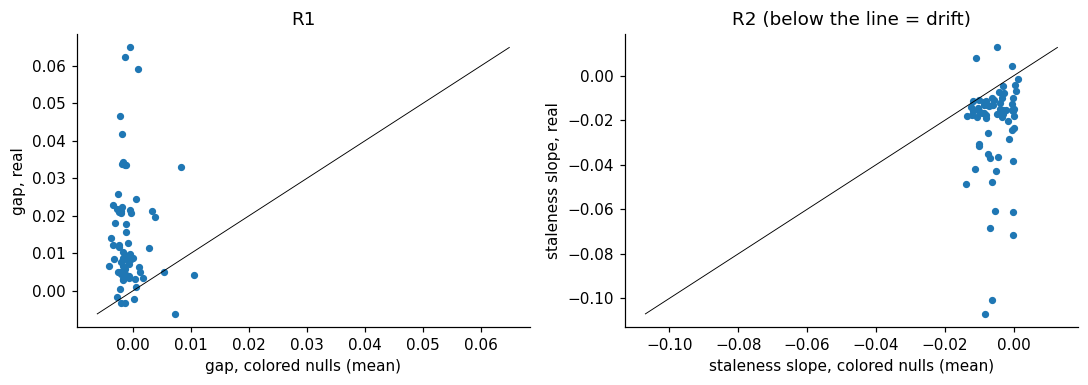

In [7]:
p2 = wtest(s_col - s_real); STALE_BEYOND = bool(p2 < 0.05)
n_stale = sum(o["real"]["slope"] < min(c["slope"] for c in o["colored"]) for o in ok.values())
print(f"median staleness slope (R² per window of distance): real {np.median(s_real):+.4f} | colored nulls {np.median(s_col):+.4f}"
      f" | drive random-walk surrogate (drift_frac 0.07) {np.median(s_rw) if len(s_rw) else float('nan'):+.4f}")
print(f"real more negative than every colored null in {n_stale}/{len(ok)} recordings; Wilcoxon p = {p2:.3g}")
for c in CUT_SENS:
    v = [o["sens"][str(c)]["slope"] for o in ok.values() if str(c) in o["sens"]]
    print(f"  sensitivity, cutoff {c} frames: median colored slope {np.median(v) if v else float('nan'):+.4f}")
print("Registered rule -> STALE beyond colored input:", STALE_BEYOND)
if len(ok):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    ax[0].scatter(g_col, g_real, s=14); lim = [min(g_col.min(), g_real.min()), max(g_col.max(), g_real.max())]
    ax[0].plot(lim, lim, "k-", lw=0.6); ax[0].set_xlabel("gap, colored nulls (mean)"); ax[0].set_ylabel("gap, real"); ax[0].set_title("R1")
    ax[1].scatter(s_col, s_real, s=14); lim = [min(s_col.min(), s_real.min()), max(s_col.max(), s_real.max())]
    ax[1].plot(lim, lim, "k-", lw=0.6); ax[1].set_xlabel("staleness slope, colored nulls (mean)"); ax[1].set_ylabel("staleness slope, real"); ax[1].set_title("R2 (below the line = drift)")
    plt.tight_layout(); plt.show()

## 4 · R3: does the tracker gain more than on colored input?

In [8]:
p3 = wtest(t_real - t_col); TRACK_BEYOND = bool(p3 < 0.05)
print(f"median tracker gain (R²): real {np.median(t_real):+.4f} | colored nulls {np.median(t_col):+.4f} | real > colored in {(t_real > t_col).sum()}/{len(ok)}, Wilcoxon p = {p3:.3g}")
print("Registered rule -> TRACK beyond colored input:", TRACK_BEYOND)

median tracker gain (R²): real +0.0236 | colored nulls -0.0007 | real > colored in 66/68, Wilcoxon p = 7.76e-13
Registered rule -> TRACK beyond colored input: True


In [9]:
out = {"n": len(ok),
       "R1": {"p": p1, "gap_beyond": GAP_BEYOND, "median_real": float(np.median(g_real)), "median_colored": float(np.median(g_col)), "redetected": int(n_new)},
       "R2": {"p": p2, "stale_beyond": STALE_BEYOND, "median_real": float(np.median(s_real)), "median_colored": float(np.median(s_col)),
              "median_rw": float(np.median(s_rw)) if len(s_rw) else None, "n_stale": int(n_stale)},
       "R3": {"p": p3, "track_beyond": TRACK_BEYOND, "median_real": float(np.median(t_real)), "median_colored": float(np.median(t_col))},
       "per_recording": rec}
json.dump(out, open(os.path.join(RESULTS, f"E3e_result{TAG}.json"), "w"), indent=2, default=float)
print("saved", f"E3e_result{TAG}.json")

saved E3e_result_laptop.json


## Results (laptop mode, 68 recordings, executed on the M1)

**All three registered rules pass. E3's drift is not colored input.**

| statistic | real (median) | colored nulls (median) | real beats nulls | Wilcoxon p | rule |
|---|---|---|---|---|---|
| refit − frozen gap | +0.0091 | −0.0014 | 62/68 | 1×10⁻¹¹ | **R1 GAP: yes** |
| staleness slope (R² per window of distance) | −0.0158 | −0.0058 | 64/68 (beyond *every* null) | 4×10⁻¹¹ | **R2 STALE: yes** |
| online tracker gain | +0.0236 | −0.0007 | 66/68 | 8×10⁻¹³ | **R3 TRACK: yes** |

* **The recording that motivated this notebook was atypical.** 2021-05-26-07 is one of only ~6 recordings whose colored nulls produce clearly positive gaps. Across all 68, stationary colored input produces *no* gap (median −0.0014), and the result holds at both sensitivity cutoffs: median colored gap −0.0003 at 50 frames and −0.0033 at 200 frames.
* **Re-detection against colored nulls gives 47/68 recordings**, the same count as with the white nulls of Notebooks 10–13.
* **The drift is larger than the planted drift.** Real programs go stale at −0.016 R² per window, vs −0.007 for the drive random-walk surrogates used in Notebooks 10–13 (drift_frac 0.07).

**Outcome: the first row of the table below.** E3's conclusion stands against realistic noise, and so do E3c's and E3d's descriptions of the drift (per-neuron drives, wandering, trackable). The caveat added to Notebooks 13 and 00 is resolved.

## 5 · Reading the result

| R2 (staleness) | R1 (gap) | reading |
|---|---|---|
| **yes ← observed** | **yes ← observed** | E3's conclusion stands against realistic noise: the program is rewritten over minutes. E3c/E3d's descriptions of the drift (per-neuron drives, wandering, trackable) are about real drift, though partly mixed with fast input. |
| yes | no | Programs really do go stale with distance, but the *gap* that E3–E3d were built on mostly measured colored input on timescales under a minute. The drift exists, and its form must be re-described with distance-based statistics. E3c/E3d's conclusions about its form apply to the colored input, not necessarily to the drift. |
| no | yes / no | E3's drift is explained by stationary input autocorrelated over tens of seconds. At the imaging level the program is **not** detectably rewritten, and C3's computer metaphor survives (with an unobserved, stationary, colored input). |

**Limits.**
* The colored nulls keep the real residuals' spectrum above the cutoff. If true drift has power at faster timescales, the nulls absorb some of it, which makes R1–R3 conservative.
* The staleness slope also reflects changes in which states the worm visits (a program fitted on one behavioral regime generalises worse to a distant, different regime). Notebook 15 (E4a) asks how much the body contributes.